In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import text_cleaning as tc
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
from analysis_utils import *

In [3]:
tqdm.pandas()

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [5]:
from constants import (
    JIBARO_WORDS, GIBARO_WORDS, CAMPESINO_WORDS, 
    LCCN_TO_NAME, BASE_PATH
)

In [6]:
nlp = spacy.blank("es")

# Load Data

In [8]:
target_df = pd.read_pickle('prelim_analysis_target_records_df.pkl')

In [9]:
len(target_df)

13920

In [10]:
texts = []
cleaned_texts = []
for idx, r in target_df.iterrows():
    with open(f"{BASE_PATH}/{r['lccn']}/{r['year']}/{r['month']}/{r['day']}/{r['edition']}/{r['sequence']}/cleaned.json") as f:
        d = json.load(f)
        texts.append(list(zip(d['text_blocks_raw'], d['text_blocks_cleaned'])))

In [11]:
target_df['texts'] = texts
# One row per block
target_df = target_df.explode('texts')
target_df['text_raw'] = target_df['texts'].apply(lambda x: x[0]['text'])
target_df['text_cleaned'] = target_df['texts'].apply(lambda x: x[1]['text'])
target_df['text_id'] = target_df['texts'].apply(lambda x: x[0]['id'])
target_df['height'] = target_df['texts'].apply(lambda x: x[0]['height'])
target_df['width'] = target_df['texts'].apply(lambda x: x[0]['width'])
target_df['hpos'] = target_df['texts'].apply(lambda x: x[0]['hpos'])
target_df['vpos'] = target_df['texts'].apply(lambda x: x[0]['vpos'])
target_df['doc_cleaned'] = target_df['text_cleaned'].progress_apply(lambda x: nlp(x))

  0%|          | 0/1026296 [00:00<?, ?it/s]

In [12]:
target_df['contains_search_word_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, JIBARO_WORDS))
target_df['contains_search_word_gibar'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, GIBARO_WORDS))
target_df['contains_search_word_campesin'] = target_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, CAMPESINO_WORDS))
target_df['surrounding_text_jibar'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20))
target_df['surrounding_text_gibar'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, GIBARO_WORDS, 20))
target_df['surrounding_text_campesino'] = target_df['doc_cleaned'].progress_apply(lambda x: get_surrounding_spans_as_doc(x, CAMPESINO_WORDS, 20))

  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

  0%|          | 0/1026296 [00:00<?, ?it/s]

In [13]:
len(target_df)

1026296

# Exclude irrelevant instances

## Build Training Dataset

In [40]:
jibar_docs_df = target_df.loc[target_df['contains_search_word_jibar']].reset_index().set_index(['link', 'text_id'])
# gibar_docs_df = target_df.loc[target_df['contains_search_word_gibar']].reset_index().set_index(['link', 'text_id'])

In [87]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl')#.reset_index()

In [93]:
# labels_data_df['word_type'] = 'jibar'

In [88]:
labels_data = labels_data_df.to_dict('records')
processed_keys = set([(d['link'], d['text_id']) for d in labels_data])

In [90]:
# Use if labelling low confidence classifier labels
# pipeline_score = gibar_pipeline.predict_proba(gibar_docs_df)[:, 1] 
# idxs = np.array(gibar_docs_df.reset_index().loc[
#         (pipeline_score > 0.5) 
#         & (pipeline_score < 0.8) 
#     ].index)

# Use if labelling based on other keywords
vectorizer = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=5)

tf_matrix = vectorizer.fit_transform(jibar_docs_df['doc_cleaned'].values).toarray()
tok_to_idx = {t: i for i, t in enumerate(vectorizer.get_feature_names_out())}
tf_matrix_surrounding = vectorizer.transform(jibar_docs_df['surrounding_text_jibar'])
idxs = np.argwhere(
    (tf_matrix_surrounding[:, tok_to_idx['amores']] > 0) #& 
    # (tf_matrix[:, tok_to_idx['jíbaro']] > 0) 
)
len(idxs)

4

In [91]:

to_label = [
    (jibar_docs_df.index[i][0], jibar_docs_df.index[i][1])
    for i in idxs.flatten()
]

In [92]:
jibar_docs_df['score'] = jibar_pipeline.predict_proba(jibar_docs_df)[:, 1]

In [93]:
for k in to_label:
    if k in processed_keys:
        continue
    print(k)
    print(jibar_docs_df.loc[k]['surrounding_text_jibar'])
    print("Score:", jibar_docs_df.loc[k]['score'])
    label = input("Label")
    if label == '-':
        continue
    labels_data.append({
        'link': k[0],
        'text_id': k[1],
        'label': int(label),
        # 'word_type': 'gibar'
        'word_type': 'jibar'
    })

('https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-08-14/ed-1/seq-2/', 'TB.0280.58')
.
y eso que, por discreción, no me
place revelar sus amores con las chicas
jíbaras, que más de una vez le aseguraron la suerte.
ah, mascotta!
veamos á 
Score: 0.3033111153117349


Label 0


('https://chroniclingamerica.loc.gov/lccn/sn86077151/1919-09-24/ed-1/seq-3/', 'P3_TB00011')
a aguí, ha venido ron
| dando su verso para la alegría de
| vivir de nuestros jíbaros, sus expansio-
' nes de tristeza o goce y sus manifesta-
| ciones de amores, 
Score: 0.2547002646906169


Label 0


In [478]:
# labels_data_df.to_pickle('jibaro_classification_labels_df.pkl')

In [94]:
pd.DataFrame.from_dict(labels_data).to_pickle('jibaro_gibaro_classification_labels_df.pkl')

In [ ]:
# labels_data_df.to_pickle('jibaro_classification_labels_df.pkl')

In [229]:
# idxs = [int(r[0]) for r in responses]
# y = [int(r[1]) for r in responses]
# X = tf_matrix[idxs,:]

# jibar_docs_surrounding = jibar_docs.iloc[idxs].apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 40))
# vectorizer2 = CountVectorizer(tokenizer=spacy_tokenizer, lowercase=False, ngram_range=(1, 2), min_df=2)
# X2 = vectorizer2.fit_transform(jibar_docs_surrounding.values).toarray()

# len(responses)


## Build Model

In [14]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl').set_index(['link', 'text_id'])
target_df = target_df.reset_index().set_index(['link', 'text_id'])
labels_data_df = pd.merge(labels_data_df, target_df, left_index=True, right_index=True)
labels_data_df.head(10)

,,level_0,index,label,word_type,lccn,date,year,month,day,edition,...,text_raw,text_cleaned,height,width,hpos,vpos,doc_cleaned,surrounding_text_jibar,surrounding_text_gibar,surrounding_text_campesino
link,text_id,,,,,,,,,,,,,,,,,,,,,
https://chroniclingamerica.loc.gov/lccn/sn91099739/1876-02-16/ed-1/seq-3/,P3_TB00001,0.0,0.0,0,jibar,sn91099739,1876-02-16,1876,02,16,ed-1,...,"se encontraba en Flor del Cayo, acü- J\ndió se...","se encontraba en flor del cayo, acü- j\ndió se...",26759,3298,1115,1531,"(se, encontraba, en, flor, del, cayo, ,, acü-,...","(1, \n, de, su, teniente, coronel, d., josé, p...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1878-05-03/ed-1/seq-4/,P4_TB00001,1.0,1.0,1,jibar,sn91099739,1878-05-03,1878,05,03,ed-1,...,EirfiiSA II T&PQRIS ESniSLES.\nCORREOS DE LAS ...,eirfiisa ii t&pqris esnisles.\ncorreos de las ...,15236,2670,883,2414,"(eirfiisa, ii, t&pqris, esnisles, ., \n, corre...",(),"(saldrá, do, la, \n, ualiana, y, uceará, 4, k,...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1879-11-23/ed-1/seq-3/,P3_TB00008,2.0,2.0,0,jibar,sn91099739,1879-11-23,1879,11,23,ed-1,...,"seis hombres, hiriendo á uno de ellos y\nlogra...","seis hombres, hiriendo á uno de ellos y\nlogra...",14500,2731,8872,1450,"(seis, hombres, ,, hiriendo, á, uno, de, ellos...","(,, recibidas, por, \n, telégrafo, ,, un, indi...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1877-12-05/ed-1/seq-3/,P3_TB00007,3.0,3.0,0,jibar,sn91099739,1877-12-05,1877,12,05,ed-1,...,L>s talleres de costura do Puerto\nPrincipe en...,l>s talleres de costura do puerto\nprincipe en...,18501,2604,6241,7857,"(l, >, s, talleres, de, costura, do, puerto, \...","(\n, las, noticias, de, estos, últimos, dias, ...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-05-09/ed-1/seq-4/,P4_TB00003,4.0,4.0,1,jibar,sn91099739,1880-05-09,1880,05,09,ed-1,...,an iim nan-nutlt\nRUTA DEL VAPOR ESPASOL\nwßan...,an iim nan-nutlt\nruta del vapor espasol\nwßan...,18931,2863,7460,1162,"(an, iim, nan-nutlt, \n, ruta, del, vapor, esp...",(),"(los, demás, \n, jtasaje, entero, ., \n, servi...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-02-08/ed-1/seq-4/,P4_TB00006,5.0,5.0,1,jibar,sn91099739,1880-02-08,1880,02,08,ed-1,...,VAFüiiES - Co¡í!!Lv3 HAÜiIUNW\nDE A. LOPEZ Y C...,vafüiies - co¡í!!lv3 haüiiunw\nde a. lopez y c...,18128,2858,7115,10620,"(vafüiies, -, co¡í!!lv3, haüiiunw, \n, de, a.,...",(),"(v, %, do, rebajis, \n, mmi, ge, u, habana, i,...",()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-02-13/ed-1/seq-3/,P3_TB00021,6.0,6.0,0,jibar,sn91099739,1880-02-13,1880,02,13,ed-1,...,Desgracia.—Parece que el otro dia en\nel Dorad...,desgracia.—parece que el otro dia en\nel dorad...,9213,2864,15562,7847,"(desgracia, ., —parece, que, el, otro, dia, en...","(literarios, en, honor, dol, malogrado, gautie...",(),()
https://chroniclingamerica.loc.gov/lccn/sn91099739/1880-06-09/ed-1/seq-4/,P4_TB00001,7.0,7.0,1,jibar,sn91099739,1880-06-09,1880,06,09,ed-1,...,wv**-' ' 1\nSIHiSiIU liÉtt ¡ftIJUS\nCORREOS DE...,v**-' ' 1\nsihisiiu liétt ¡ftijus\ncorreos de ...,27033,2920,1318,1852,"(v**-, ', ', 1, \n, sihisiiu, liétt, ¡, ftijus...",(),"(illa, mil, ., \n, fli, .ii, a, n.ii'vltab, e....",()
https://chroniclingamerica.loc.gov/lccn/sn86077151/1923-11-05/ed-1/seq-2/,P2_TB00001,8.0,8.0,0,jibar,sn86077151,1923-11-05,1923,11,05,ed-1,...,ae S Te D S E TA\nEL MINDO\n¿¿VERBA_Q! Y Jº» ¿...,ae s te d s e ta\nel mindo\n¿¿verbal! y jº» ¿e...,22970,2769,647,1148,"(ae, s, te, d, s, e, ta, \n, el, mindo, \n, ¿,...","(artistas, \n, ', ”, …, ', y, ., “, -$s, ., …,...",(),()


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [17]:

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding_jibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_jibar'),
        ('tfidf_surrounding_gibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_gibar')
    ],
    remainder='drop'
)

base_svm = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('calibrated_svm', calibrated_svm),
    ]
)


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = cross_validate(
    pipeline,
    X=labels_data_df,
    y=labels_data_df['label'],
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9318181818181819), 'test_precision': np.float64(0.965385885813306), 'test_recall': np.float64(0.9331073446327685), 'test_f1': np.float64(0.9489145453166434), 'test_roc_auc': np.float64(0.9776988533578248)}


In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding_jibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_jibar')
    ],
    remainder='drop'
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

selected_labels_df = labels_data_df.loc[labels_data_df['word_type'] == 'jibar']
jibar_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('calibrated_svm', calibrated_svm),
    ]
)

jibar_pipeline.fit(selected_labels_df, selected_labels_df['label'])

,steps,"[('preprocessor', ...), ('calibrated_svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf_doc_cleaned', ...), ('tfidf_surrounding_jibar', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
selected_labels_df = labels_data_df.loc[labels_data_df['word_type'] == 'gibar']

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf_doc_cleaned', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2), 'doc_cleaned'),
        ('tfidf_surrounding_gibar', TfidfVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2), 'surrounding_text_gibar')
    ],
    remainder='drop'
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)


gibar_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('calibrated_svm', calibrated_svm),
    ]
)

gibar_pipeline.fit(selected_labels_df, selected_labels_df['label'])

,steps,"[('preprocessor', ...), ('calibrated_svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf_doc_cleaned', ...), ('tfidf_surrounding_gibar', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [325]:
pred_y = gibar_pipeline.predict_proba(labels_data_df)[:, 1]

(array([ 21.,  17.,   1.,   0.,   0.,   0.,   3.,  52.,  75., 271.]),
 array([0.01295851, 0.11143122, 0.20990393, 0.30837665, 0.40684936,
        0.50532207, 0.60379479, 0.7022675 , 0.80074021, 0.89921292,
        0.99768564]),
 <BarContainer object of 10 artists>)

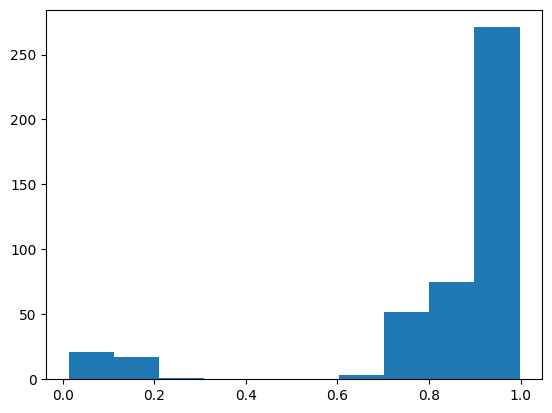

In [326]:
plt.hist(pred_y)

In [360]:
with open('models/jibar_pipeline.pkl', 'wb') as f:
    pickle.dump(jibar_pipeline, f)

with open('models/gibar_pipeline.pkl', 'wb') as f:
    pickle.dump(gibar_pipeline, f)

In [21]:
with open('models/jibar_pipeline.pkl', 'rb') as f:
    jibar_pipeline = pickle.load(f)

with open('models/gibar_pipeline.pkl', 'rb') as f:
    gibar_pipeline = pickle.load(f)

# Label with Model and Annotations

In [60]:
labels_data_df = pd.read_pickle('jibaro_gibaro_classification_labels_df.pkl')
labels_data_df = labels_data_df[['link', 'text_id', 'word_type', 'label']].drop_duplicates().set_index(['link', 'text_id'])
if 'level_0' in labels_data_df.columns:
    del labels_data_df['level_0']
target_df = target_df.reset_index().set_index(['link', 'text_id'])
data_df = target_df.join(labels_data_df, how='left')

In [61]:
scores = gibar_pipeline.predict_proba(data_df)[:, 1]
data_df['relvent_gibar_doc_score'] =  scores

In [62]:
scores = jibar_pipeline.predict_proba(data_df)[:, 1]
data_df['relvent_jibar_doc_score'] =  scores

In [63]:
data_df['relevant_jibar_doc'] = data_df.apply(
    lambda r: (r['label'] == 0) if pd.notna(r['label']) else (r['contains_search_word_jibar'] > 0) and (r['relvent_jibar_doc_score'] < 0.5), 
    axis=1
)

In [64]:
data_df['relevant_gibar_doc'] = data_df.apply(
    lambda r: (r['label'] == 0) if pd.notna(r['label']) else (r['contains_search_word_gibar'] > 0) and (r['relvent_gibar_doc_score'] < 0.5), 
    axis=1
)

In [65]:
data_df['relevant_campesin_doc'] = (data_df['contains_search_word_campesin'] > 0)

In [67]:
data_df['relevant_jibar_doc'].sum(), data_df['relevant_gibar_doc'].sum(), data_df['relevant_campesin_doc'].sum()

(np.int64(1837), np.int64(131), np.int64(5378))

## Analyze

## Timeline

In [40]:

import matplotlib.ticker as mtick

In [70]:
data_df['contains_search_word_jibar'] = data_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, JIBARO_WORDS))
data_df['contains_search_word_gibar'] = data_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, GIBARO_WORDS))
data_df['contains_search_word_campesin'] = data_df['doc_cleaned'].progress_apply(lambda x: contains_search_word(x, CAMPESINO_WORDS))


  0%|          | 0/1026297 [00:00<?, ?it/s]

  0%|          | 0/1026297 [00:00<?, ?it/s]

  0%|          | 0/1026297 [00:00<?, ?it/s]

In [71]:
data_df['doc_length'] = data_df['doc_cleaned'].progress_apply(len)

  0%|          | 0/1026297 [00:00<?, ?it/s]

In [73]:
data_df['is_relevant'] = data_df['relevant_jibar_doc'] | data_df['relevant_gibar_doc'] | data_df['relevant_campesin_doc']

In [ ]:
data_df.head(10)

In [74]:
data_df = data_df.reset_index()

In [75]:
data_df.groupby(['link', 'text_id'])['lccn'].count().to_frame('c').reset_index().groupby('c').count()


,link,text_id
c,,
1,1026295,1026295
2,1,1


In [76]:
t = data_df.loc[data_df['is_relevant']]

In [77]:
t.head(10)

,link,text_id,lccn,date,year,month,day,edition,sequence,total_tokens,...,surrounding_text_campesino,word_type,label,relvent_gibar_doc_score,relvent_jibar_doc_score,relevant_jibar_doc,relevant_gibar_doc,relevant_campesin_doc,doc_length,is_relevant
316,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0215.22,sn90070270,1897-03-03,1897,03,03,ed-1,seq-2,5083,...,(),jibar,0.0,0.733488,0.012230,True,True,False,762,True
1463,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0275.14,sn90070270,1897-03-20,1897,03,20,ed-1,seq-2,4243,...,(),NaN,NaN,0.669962,0.228722,True,False,False,494,True
1466,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0275.17,sn90070270,1897-03-20,1897,03,20,ed-1,seq-2,4243,...,(),NaN,NaN,0.809878,0.177388,True,False,False,606,True
1881,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0300.201,sn90070270,1897-03-27,1897,03,27,ed-1,seq-3,5940,...,(),NaN,NaN,0.849186,0.017292,True,False,False,9,True
2443,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0304.15,sn90070270,1897-03-29,1897,03,29,ed-1,seq-3,5086,...,"(registro, de, la, propiedad, y, el, xegistro,...",NaN,NaN,0.844433,0.411166,False,False,True,427,True
2532,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0304.104,sn90070270,1897-03-29,1897,03,29,ed-1,seq-3,5086,...,(),NaN,NaN,0.786644,0.022326,True,False,False,132,True
2944,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0303.6,sn90070270,1897-03-29,1897,03,29,ed-1,seq-2,4976,...,"(no, existe, ni, el, mo-, \n, tivo, más, remot...",NaN,NaN,0.849358,0.295297,False,False,True,648,True
4170,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0312.3,sn90070270,1897-03-31,1897,03,31,ed-1,seq-3,4794,...,(),NaN,NaN,0.552245,0.009857,True,False,False,861,True
4392,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0311.6,sn90070270,1897-03-31,1897,03,31,ed-1,seq-2,5357,...,"(tenemos, \n, un, verdadero, lujo, de, escuela...",NaN,NaN,0.754255,0.022606,True,False,True,1004,True
4439,https://chroniclingamerica.loc.gov/lccn/sn9007...,TB.0308.4,sn90070270,1897-03-30,1897,03,30,ed-1,seq-3,6279,...,(),NaN,NaN,0.762631,0.257082,True,False,False,1077,True


In [79]:
data_df.loc[data_df['is_relevant']].to_pickle('relevant_docs_df.pkl')

In [75]:
def _doc_agg(g):
    jibar_sums = g.loc[g['relevant_jibar_doc']]['contains_search_word_jibar'].sum()
    gibar_sums = g.loc[g['relevant_gibar_doc']]['contains_search_word_gibar'].sum()
    campesin_sums =  g.loc[g['relevant_campesin_doc']]['contains_search_word_campesin'].sum()
    l = g['doc_length'].sum()
    
    return pd.Series({
        'year': g.iloc[0]['year'],
        'title': g.iloc[0]['title'],
        'jibar_freq': jibar_sums / l,
        'gibar_freq': gibar_sums / l,
        'campesin_freq': campesin_sums / l,
        'jibaro_gibaro_freq': (jibar_sums + gibar_sums)/l,
        'doc_length': l
    })
        

per_doc_df = (
    data_df
    .reset_index()
    .groupby('link')
    .progress_apply(_doc_agg, include_groups=False)
)

  0%|          | 0/13920 [00:00<?, ?it/s]

In [76]:
# Doc frequency
# plot_df = (
#     data_df
#     .reset_index()
#     .groupby('link')
#     .agg({
#         'relevant_jibar_doc': lambda x: x.sum() > 0,
#         'relevant_gibar_doc': lambda x: x.sum() > 0,
#         'relevant_campesin_doc': lambda x: x.sum() > 0,
#         'year': 'min',
#         'title': 'min'
#     })
#     .reset_index()
#     .groupby(['year', 'title'])[['relevant_jibar_doc', 'relevant_gibar_doc', 'relevant_campesin_doc']]
#     .mean()
#     .reset_index()
# )

# Doc frequency
plot_df = (
    per_doc_df
    .reset_index()
    .groupby(['year', 'title'])[['jibar_freq', 'gibar_freq', 'campesin_freq', 'jibaro_gibaro_freq']]
    .mean()
    .reset_index()
)

plot_df.columns

Index(['year', 'title', 'jibar_freq', 'gibar_freq', 'campesin_freq',
       'jibaro_gibaro_freq'],
      dtype='object')

In [77]:
plot_df.columns = ['year', 'title', 'relevant_jibar_doc', 'relevant_gibar_doc', 'relevant_campesin_doc', 'relevant_jibar_gibar_doc']

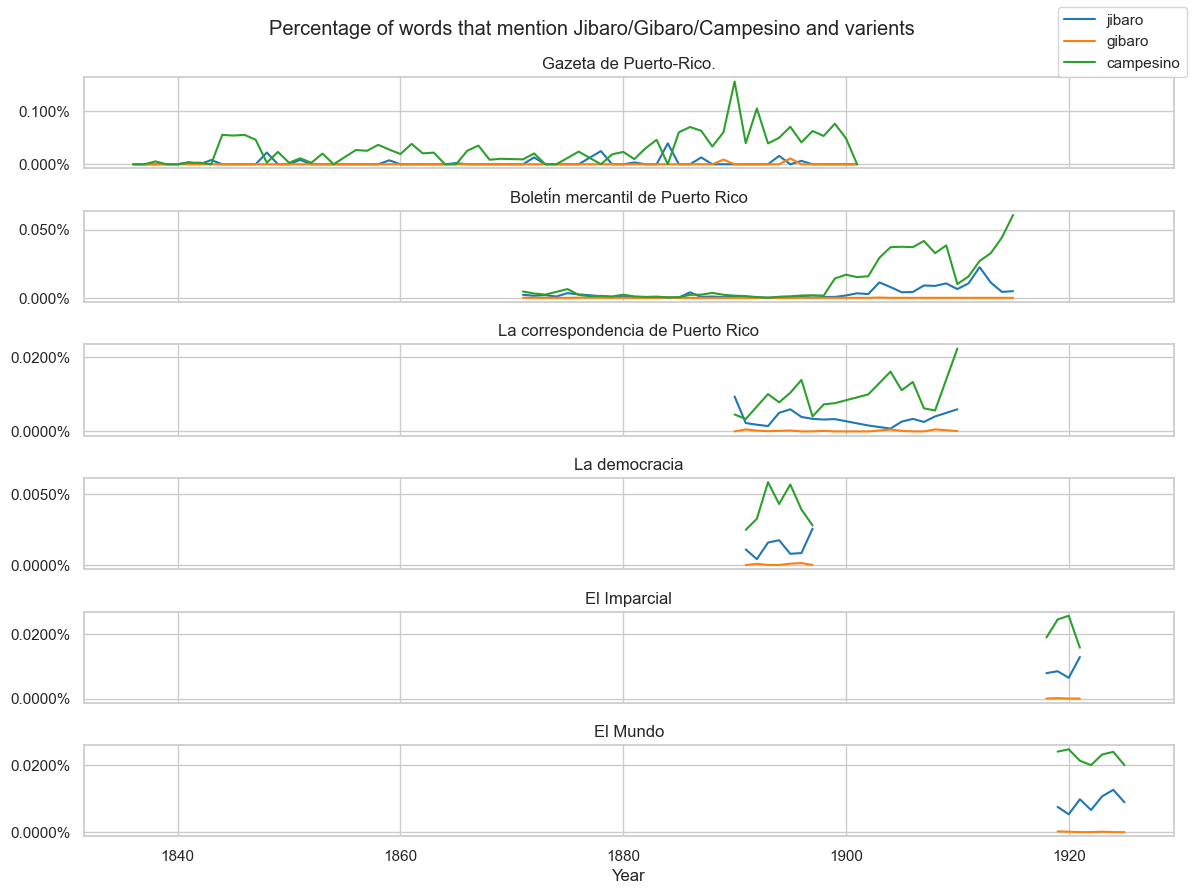

In [73]:
sns.set_theme(style="whitegrid")


plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'relevant_jibar_doc': 'tab:blue',
    'relevant_gibar_doc': 'tab:orange',
    'relevant_campesin_doc': 'tab:green'
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['relevant_jibar_doc'],
        color=freq_colors['relevant_jibar_doc'],
        label='jibaro'
    )

    ax.plot(
        df_t['year'],
        df_t['relevant_gibar_doc'],
        color=freq_colors['relevant_gibar_doc'],
        label='gibaro'
    )

    ax.plot(
        df_t['year'],
        df_t['relevant_campesin_doc'],
        color=freq_colors['relevant_campesin_doc'],
        label='campesino'
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title)
    # ax.set_ylabel("Frequency")

axes[-1].set_xlabel("Year")

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Percentage of words that mention Jibaro/Gibaro/Campesino and varients")
plt.tight_layout()
plt.show()


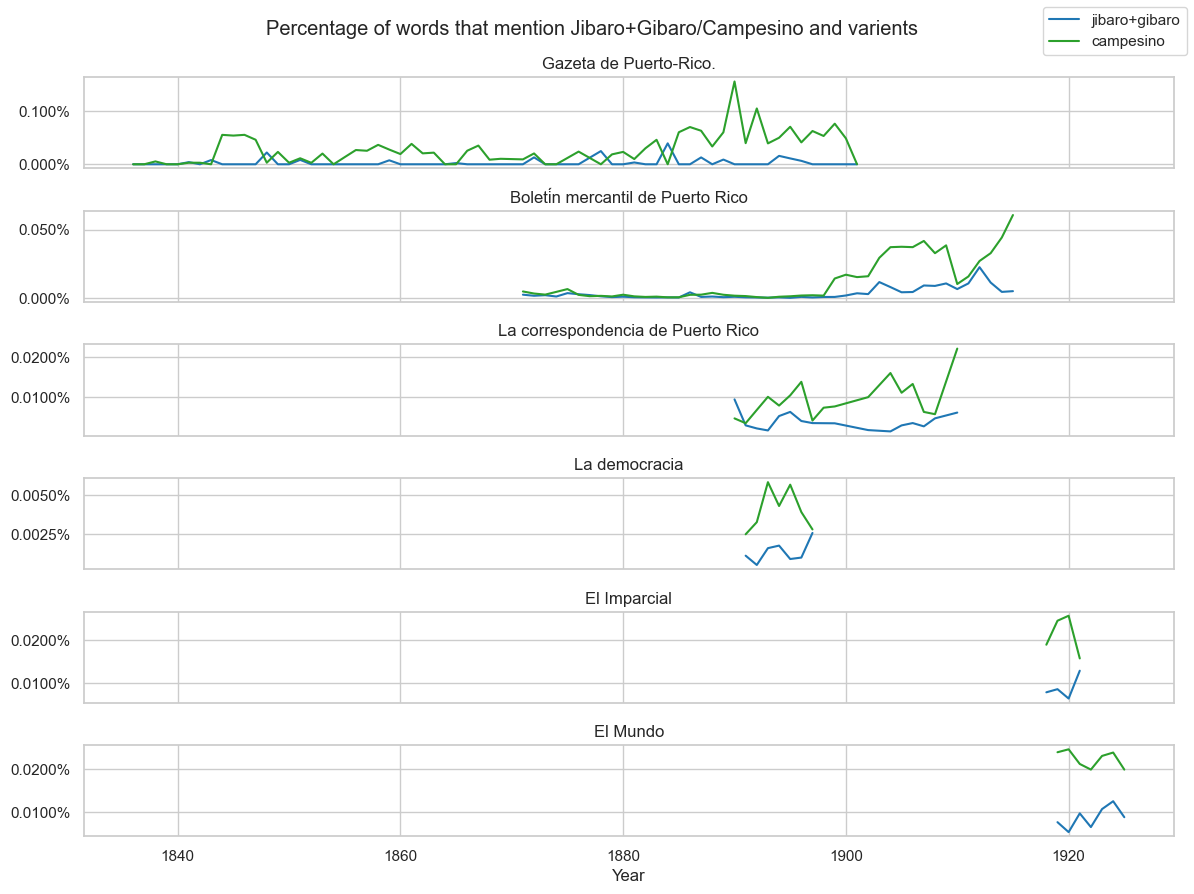

In [80]:
sns.set_theme(style="whitegrid")


plot_df['year'] = pd.to_numeric(plot_df['year'])
freq_colors = {
    'relevant_jibar_gibar_doc': 'tab:blue',
    'relevant_campesin_doc': 'tab:green'
}
titles = plot_df['title'].unique()
n_titles = len(titles)

fig, axes = plt.subplots(
    n_titles,
    1,
    figsize=(12, 1.5 * n_titles),
    sharex=True
)

for ax, title in zip(axes, titles):
    df_t = plot_df[plot_df['title'] == title]

    ax.plot(
        df_t['year'],
        df_t['relevant_jibar_gibar_doc'],
        color=freq_colors['relevant_jibar_gibar_doc'],
        label='jibaro+gibaro'
    )
    ax.plot(
        df_t['year'],
        df_t['relevant_campesin_doc'],
        color=freq_colors['relevant_campesin_doc'],
        label='campesino'
    )
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_title(title)
    # ax.set_ylabel("Frequency")

axes[-1].set_xlabel("Year")

# Create one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Percentage of words that mention Jibaro+Gibaro/Campesino and varients")
plt.tight_layout()
plt.show()


## Word Clouds

In [123]:
from wordcloud import WordCloud

In [125]:
data_df['decade'] = (data_df['year'].astype(int) // 10) * 10

In [ ]:
data_df['surrounding_text_jibar

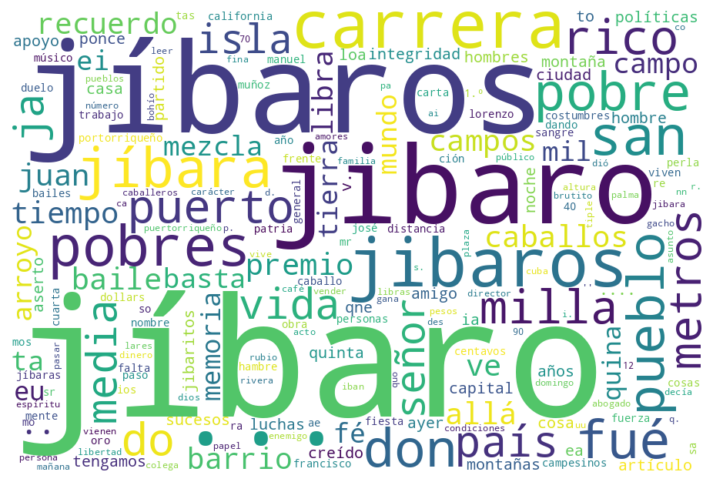

In [139]:
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
]

tfs = get_term_freqs(selected_df['surrounding_text_jibar'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

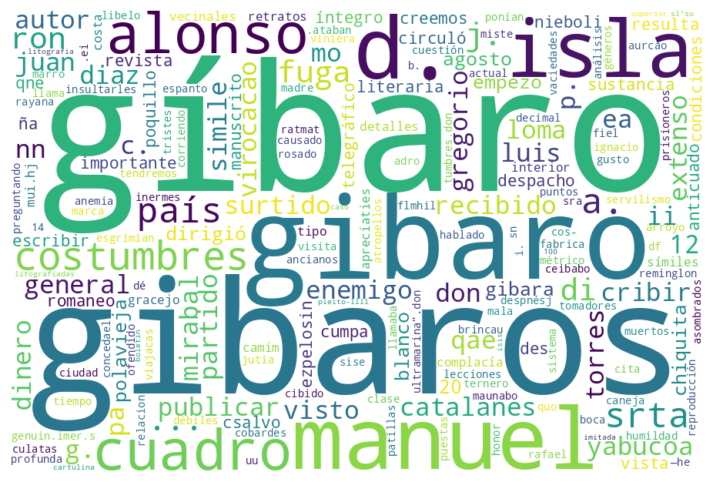

In [140]:
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'gibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_gibar'] & (data_df['relvent_gibar_doc_score'] < 0.5))
]

tfs = get_term_freqs(selected_df['surrounding_text_gibar'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

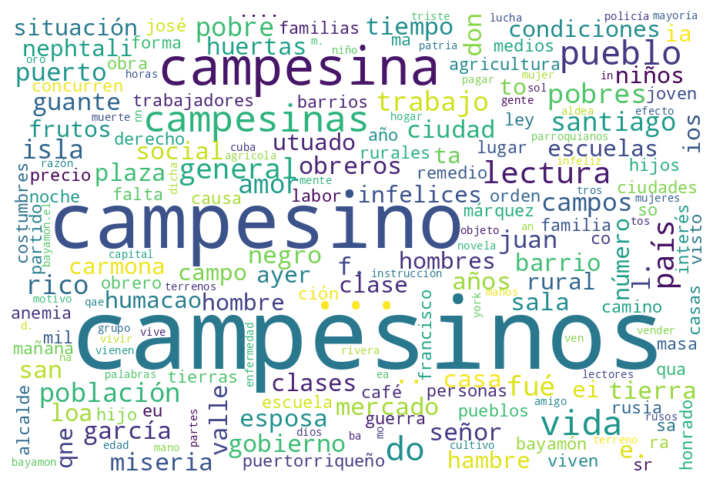

In [142]:
selected_df = data_df.loc[
    data_df['contains_search_word_campesin']
]

tfs = get_term_freqs(selected_df['surrounding_text_campesino'])
width = 900
height = 600
wc = WordCloud(
    width=width,height=height,
    background_color='white'
)
wc.generate_from_frequencies(tfs['tf'])
plt.figure(figsize=(width/100, height/100))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

Generating word cloud for decade: (1840, 'tf')


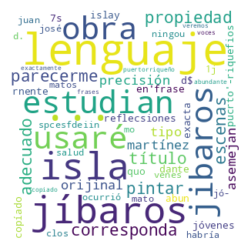

Generating word cloud for decade: (1850, 'tf')


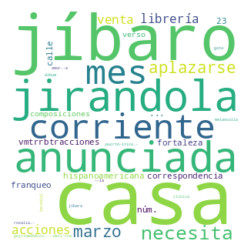

Generating word cloud for decade: (1860, 'tf')


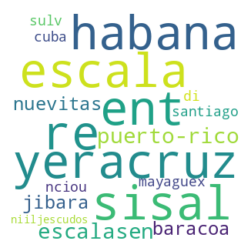

Generating word cloud for decade: (1870, 'tf')


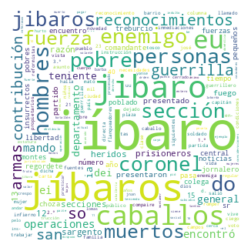

Generating word cloud for decade: (1880, 'tf')


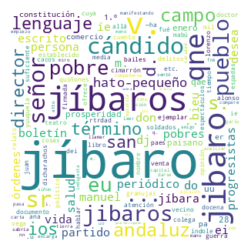

Generating word cloud for decade: (1890, 'tf')


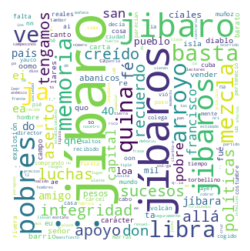

Generating word cloud for decade: (1900, 'tf')


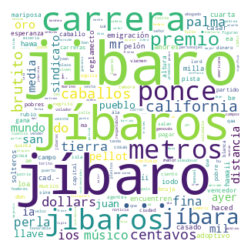

Generating word cloud for decade: (1910, 'tf')


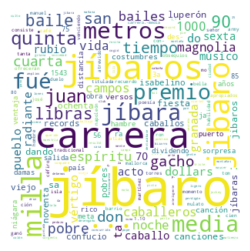

Generating word cloud for decade: (1920, 'tf')


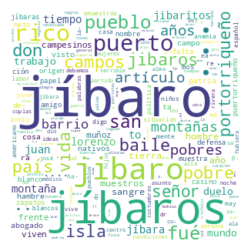

In [143]:
width = 300
height = 300
for i, row in t.iterrows():
    print(f"Generating word cloud for decade: {i}")
    wc = WordCloud(
        width=width,height=height,
        background_color='white'
    )
    wc.generate_from_frequencies(row['surrounding_text_jibar'])
    plt.figure(figsize=(width/100, height/100))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [ ]:
import math
import matplotlib.pyplot as plt
from wordcloud import WordCloud

width = 300
height = 300
n_cols = 4
n_items = len(t)

In [160]:
# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
# ]
# t = selected_df.groupby('decade')['surrounding_text_jibar'].apply(get_term_freqs).to_frame()

# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'gibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_gibar'] & (data_df['relvent_gibar_doc_score'] < 0.5))
# ]
# t = selected_df.groupby('decade')['surrounding_text_gibar'].apply(get_term_freqs).to_frame()

selected_df = data_df.loc[
    data_df['contains_search_word_campesin']
]
t = selected_df.groupby('decade')['surrounding_text_campesino'].apply(get_term_freqs).to_frame()

t.columns = ['surrounding_text']

Generating word cloud for decade: (1830, 'tf')
Generating word cloud for decade: (1840, 'tf')
Generating word cloud for decade: (1850, 'tf')
Generating word cloud for decade: (1860, 'tf')
Generating word cloud for decade: (1870, 'tf')
Generating word cloud for decade: (1880, 'tf')
Generating word cloud for decade: (1890, 'tf')
Generating word cloud for decade: (1900, 'tf')
Generating word cloud for decade: (1910, 'tf')
Generating word cloud for decade: (1920, 'tf')


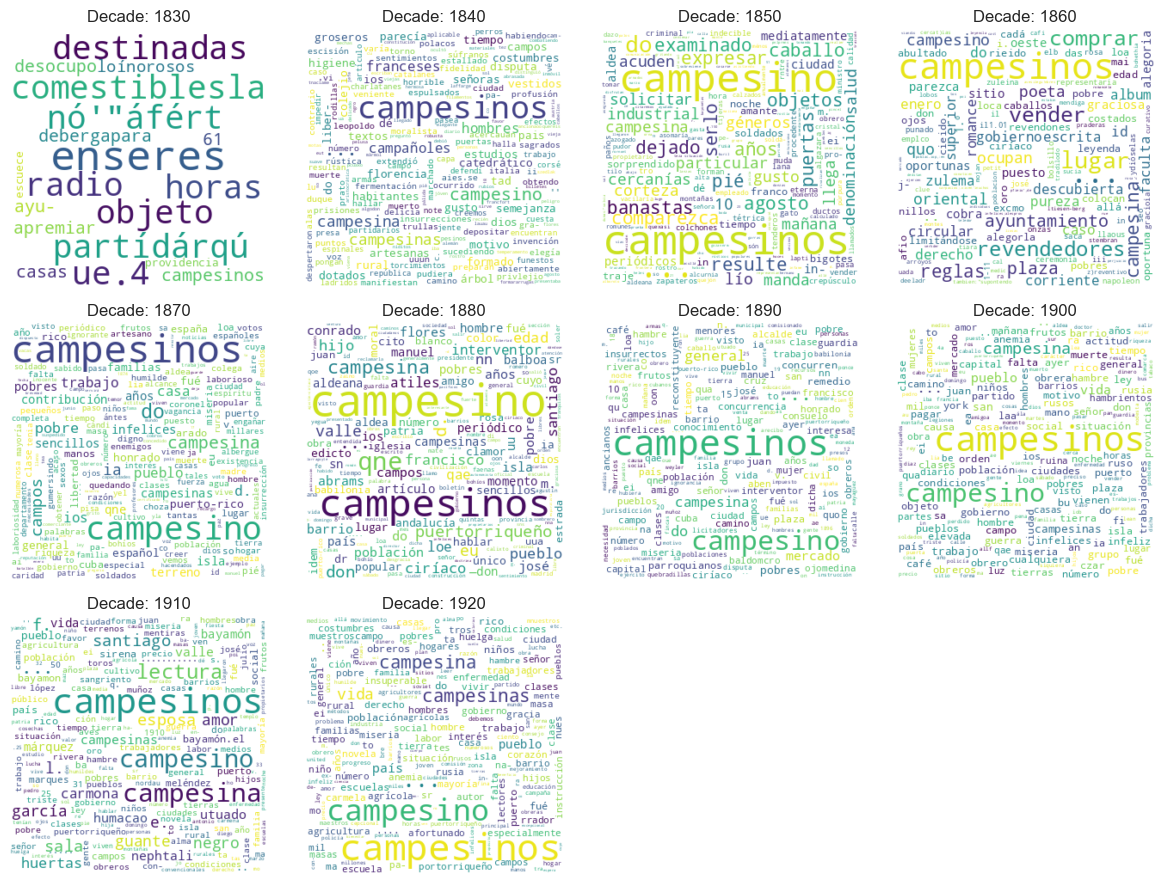

In [161]:
n_cols = 4
n_items = len(t)

n_rows = math.ceil(n_items / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * width / 100, n_rows * height / 100)
)

# If there's only one row, axes won't be 2D — normalize it
axes = axes.flatten()

for ax, (i, row) in zip(axes, t.iterrows()):
    print(f"Generating word cloud for decade: {i}")

    wc = WordCloud(
        width=width,
        height=height,
        background_color="white"
    ).generate_from_frequencies(row["surrounding_text"])

    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Decade: {i[0]}")
    ax.axis("off")
    # ax.set_frame_on(True)
    # # 🔲 add black border
    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    #     spine.set_edgecolor("black")
    #     spine.set_linewidth(1.5)
        
# Turn off any leftover empty subplots
for ax in axes[n_items:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [153]:
i

(1920, 'tf')

In [26]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [84]:
# selected_df = data_df.loc[data_df['relevant_jibar_doc']]
selected_df = data_df.loc[
    (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
    | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
]
tfs = get_term_freqs(selected_df['surrounding_text_jibar'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbaro', 1064),
 ('jíbaros', 542),
 ('jibaro', 396),
 ('...', 282),
 ('jibaros', 128),
 ('carrera', 122),
 ('pobres', 88),
 ('san', 83),
 ('jíbara', 82),
 ('pobre', 76),
 ('fué', 75),
 ('don', 74),
 ('pueblo', 69),
 ('rico', 61),
 ('puerto', 57),
 ('milla', 57),
 ('do', 53),
 ('metros', 53),
 ('país', 50),
 ('vida', 49),
 ('media', 48),
 ('ja', 47),
 ('señor', 47),
 ('isla', 46),
 ('premio', 46),
 ('baile', 45),
 ('juan', 44),
 ('caballos', 43),
 ('..', 42),
 ('campos', 41),
 ('ve', 40),
 ('allá', 39),
 ('tiempo', 39),
 ('recuerdo', 36),
 ('barrio', 36),
 ('libra', 34),
 ('campo', 34),
 ('mezcla', 33),
 ('basta', 33),
 ('ei', 33),
 ('ta', 33),
 ('tierra', 33),
 ('mil', 33),
 ('fé', 32),
 ('arroyo', 32),
 ('mundo', 32),
 ('memoria', 31),
 ('eu', 31),
 ('quina', 30),
 ('integridad', 30),
 ('luchas', 30),
 ('tengamos', 30),
 ('qne', 30),
 ('ea', 30),
 ('capital', 30),
 ('creído', 29),
 ('políticas', 29),
 ('aserto', 29),
 ('apoyo', 29),
 ('sucesos', 29),
 ('amigo', 29),
 ('años', 28),


In [96]:
len(selected_df)

1698

In [85]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(selected_df['surrounding_text_jibar']).toarray()

In [95]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.sum(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('pobre jíbaro', np.int64(54)),
 ('puerto rico', np.int64(43)),
 ('pobres jíbaros', np.int64(42)),
 ('pobres jibaros', np.int64(34)),
 ('media milla', np.int64(33)),
 ('allá fé', np.int64(29)),
 ('allá fé pobres', np.int64(29)),
 ('allá fé pobres jibaros', np.int64(29)),
 ('apoyo allá', np.int64(29)),
 ('apoyo allá fé', np.int64(29)),
 ('apoyo allá fé pobres', np.int64(29)),
 ('arroyo recuerdo', np.int64(29)),
 ('arroyo recuerdo basta', np.int64(29)),
 ('aserto apoyo', np.int64(29)),
 ('aserto apoyo allá', np.int64(29)),
 ('aserto apoyo allá fé', np.int64(29)),
 ('creído jíbaro', np.int64(29)),
 ('creído jíbaro mezcla', np.int64(29)),
 ('creído jíbaro mezcla luchas', np.int64(29)),
 ('fé pobres', np.int64(29)),
 ('fé pobres jibaros', np.int64(29)),
 ('fé pobres jibaros sucesos', np.int64(29)),
 ('integridad creído', np.int64(29)),
 ('integridad creído jíbaro', np.int64(29)),
 ('integridad creído jíbaro mezcla', np.int64(29)),
 ('ja integridad', np.int64(29)),
 ('ja integridad creído',

In [30]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.sum(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('amores reglamecto', np.int64(6)),
 ('amores reglamecto íi', np.int64(6)),
 ('amores reglamecto íi jíbaro', np.int64(6)),
 ('apropiados ofrecerán', np.int64(6)),
 ('bailes jíbaros', np.int64(6)),
 ('bailes jíbaros canciones', np.int64(6)),
 ('bailes jíbaros canciones obsequios', np.int64(6)),
 ('canciones obsequios', np.int64(6)),
 ('canciones obsequios apropiados', np.int64(6)),
 ('canciones obsequios apropiados ofrecerán', np.int64(6)),
 ('casado hawa', np.int64(6)),
 ('casar ios', np.int64(6)),
 ('casar ios amores', np.int64(6)),
 ('casar ios amores reglamecto', np.int64(6)),
 ('consiste bailes', np.int64(6)),
 ('consiste bailes jíbaros', np.int64(6)),
 ('consiste bailes jíbaros canciones', np.int64(6)),
 ('emigración hawaii', np.int64(6)),
 ('emigración hawaii haced', np.int64(6)),
 ('emigración hawaii haced casar', np.int64(6)),
 ('encuentren solteros', np.int64(6)),
 ('encuentren solteros iodo', np.int64(6)),
 ('encuentren solteros iodo mundo', np.int64(6)),
 ('fiesta tradicion

In [413]:
len(selected_df)

146

In [108]:
selected_df = data_df.loc[data_df['relevant_gibar_doc']]
# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
# ]
tfs = get_term_freqs(selected_df['surrounding_text_gibar'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('gíbaro', 18),
 ('gibaros', 14),
 ('gibaro', 12),
 ('manuel', 6),
 ('d.', 6),
 ('isla', 5),
 ('alonso', 5),
 ('cuadro', 5),
 ('costumbres', 5),
 ('país', 4),
 ('a.', 4),
 ('srta', 4),
 ('ron', 3),
 ('di', 3),
 ('...', 3),
 ('fuga', 3),
 ('j.', 3),
 ('ii', 2),
 ('general', 2),
 ('cribir', 2),
 ('publicar', 2),
 ('don', 2),
 ('diaz', 2),
 ('yabucoa', 2),
 ('visto', 2),
 ('12', 2),
 ('loma', 2),
 ('enemigo', 2),
 ('nn', 2),
 ('extenso', 2),
 ('surtido', 2),
 ('catalanes', 2),
 ('recibido', 2),
 ('c.', 2),
 ('virocacao', 2),
 ('autor', 2),
 ('luis', 2),
 ('juan', 2),
 ('g.', 2),
 ('gregorio', 2),
 ('torres', 2),
 ('mirabal', 2),
 ('partido', 2),
 ('mo', 2),
 ('simile', 2),
 ('pa', 2),
 ('p.', 2),
 ('dinero', 2),
 ('qae', 2),
 ('ea', 2),
 ('chiquita', 1),
 ('empezo', 1),
 ('20', 1),
 ('agosto', 1),
 ('dirigió', 1),
 ('polavieja', 1),
 ('blanco', 1),
 ('gibara', 1),
 ('importante', 1),
 ('despacho', 1),
 ('telegráfico', 1),
 ('íntegro', 1),
 ('vista', 1),
 ('qne', 1),
 ('sustancia', 1),
 (

In [110]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(selected_df['surrounding_text_gibar']).toarray()

In [112]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.mean(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('gíbaro cuadro', np.float64(0.02824858757062147)),
 ('manuel alonso', np.float64(0.02824858757062147)),
 ('cuadro costumbres', np.float64(0.022598870056497175)),
 ('gíbaro cuadro costumbres', np.float64(0.022598870056497175)),
 ('costumbres di', np.float64(0.011299435028248588)),
 ('costumbres di isla', np.float64(0.011299435028248588)),
 ('costumbres di isla manuel', np.float64(0.011299435028248588)),
 ('costumbres isla', np.float64(0.011299435028248588)),
 ('cuadro costumbres di', np.float64(0.011299435028248588)),
 ('cuadro costumbres di isla', np.float64(0.011299435028248588)),
 ('di isla', np.float64(0.011299435028248588)),
 ('di isla manuel', np.float64(0.011299435028248588)),
 ('extenso surtido', np.float64(0.011299435028248588)),
 ('gíbaro cuadro costumbres di', np.float64(0.011299435028248588)),
 ('isla manuel', np.float64(0.011299435028248588)),
 ('nn extenso', np.float64(0.011299435028248588)),
 ('nn extenso surtido', np.float64(0.011299435028248588))]

In [113]:
selected_df = data_df.loc[data_df['contains_search_word_campesin']]
# selected_df = data_df.loc[
#     (pd.notna(data_df['label']) & (data_df['word_type'] == 'jibar') & (data_df['label'] == 0))
#     | (data_df['contains_search_word_jibar'] & (data_df['relvent_jibar_doc_score'] < 0.5))
# ]
tfs = get_term_freqs(selected_df['surrounding_text_campesino'])
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('campesinos', 3498),
 ('campesino', 1914),
 ('campesina', 677),
 ('...', 651),
 ('campesinas', 303),
 ('vida', 251),
 ('pueblo', 240),
 ('do', 225),
 ('lectura', 191),
 ('país', 169),
 ('general', 157),
 ('pobres', 152),
 ('fué', 150),
 ('trabajo', 139),
 ('santiago', 135),
 ('isla', 134),
 ('población', 132),
 ('amor', 130),
 ('pobre', 127),
 ('rico', 127),
 ('campos', 122),
 ('puerto', 121),
 ('..', 116),
 ('esposa', 116),
 ('f.', 114),
 ('obreros', 112),
 ('sala', 112),
 ('tierra', 109),
 ('mercado', 106),
 ('miseria', 105),
 ('tiempo', 103),
 ('juan', 102),
 ('señor', 101),
 ('garcía', 101),
 ('l.', 100),
 ('gobierno', 99),
 ('negro', 98),
 ('san', 97),
 ('casa', 97),
 ('e.', 97),
 ('ciudad', 95),
 ('años', 95),
 ('don', 94),
 ('social', 94),
 ('guante', 92),
 ('plaza', 85),
 ('valle', 85),
 ('clases', 84),
 ('barrio', 83),
 ('loa', 83),
 ('huertas', 83),
 ('utuado', 80),
 ('hombres', 79),
 ('número', 78),
 ('ios', 77),
 ('qne', 76),
 ('ei', 75),
 ('ta', 75),
 ('humacao', 75),
 (

In [114]:
len(selected_df)

5380

In [115]:
cv = CountVectorizer(tokenizer=spacy_tokenizer, token_pattern=None, lowercase=False, min_df=2, ngram_range=(2, 4))
vec = cv.fit_transform(selected_df['surrounding_text_campesino']).toarray()

In [116]:
bigram_tfs = zip(cv.get_feature_names_out(), vec.mean(axis=0))
sorted(bigram_tfs, key=lambda item: -item[1])

[('lectura campesina', np.float64(0.03308550185873606)),
 ('campesinos santiago', np.float64(0.018773234200743494)),
 ('sala garcía', np.float64(0.018029739776951673)),
 ('puerto rico', np.float64(0.016728624535315983)),
 ('guante negro', np.float64(0.015799256505576207)),
 ('pobres campesinos', np.float64(0.015055762081784387)),
 ('amor esposa', np.float64(0.01449814126394052)),
 ('santiago carmona', np.float64(0.0137546468401487)),
 ('campesinos santiago carmona', np.float64(0.01245353159851301)),
 ('nephtali sala', np.float64(0.012267657992565056)),
 ('humacao amor', np.float64(0.012081784386617101)),
 ('nephtali sala garcía', np.float64(0.011895910780669145)),
 ('garcía utuado', np.float64(0.011524163568773234)),
 ('sala garcía utuado', np.float64(0.011524163568773234)),
 ('utuado campesinos', np.float64(0.01133828996282528)),
 ('humacao amor esposa', np.float64(0.011152416356877323)),
 ('pobre campesino', np.float64(0.010966542750929368)),
 ('esposa nephtali', np.float64(0.0107806

In [96]:
cv.get_feature_names_out()

array(['abad jíbaro', 'abandonan montaña', 'abandonan montaña deber', ...,
       'ña cayey', 'ña cayey esfuerzo', 'ña cayey esfuerzo andrea'],
      shape=(1374,), dtype=object)

In [248]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import make_scorer, f1_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_validate

In [452]:

base_svm = LinearSVC(
    C=1.0,
    # class_weight="auto",
    random_state=42,
    max_iter=20000
)

calibrated_svm = CalibratedClassifierCV(
    estimator=base_svm,
    method="sigmoid",   # Platt scaling
    cv=5,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = cross_validate(
    calibrated_svm,
    # X=X,
    X=X2,
    y=y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1,
)

print({k: np.mean(v) for k, v in results.items() if k.startswith("test_")})

{'test_accuracy': np.float64(0.9022222222222223), 'test_precision': np.float64(0.910865105908584), 'test_recall': np.float64(0.9103333333333333), 'test_f1': np.float64(0.9102992345874521), 'test_roc_auc': np.float64(0.9477619047619047)}


In [446]:
np.mean(y)

np.float64(0.5466666666666666)

In [453]:
calibrated_svm.fit(X2, y)

,estimator,LinearSVC(max...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'


In [454]:
pred_y = calibrated_svm.predict_proba(tf_matrix)[:, 1]

In [ ]:
np.argwhere((pred_y > 0.3) & (pred_y < 0.6)).flatten()

(array([67., 26., 10.,  0.,  0.,  0.,  2.,  5., 47., 68.]),
 array([3.00314445e-04, 9.98401943e-02, 1.99380074e-01, 2.98919954e-01,
        3.98459834e-01, 4.97999714e-01, 5.97539594e-01, 6.97079474e-01,
        7.96619354e-01, 8.96159234e-01, 9.95699113e-01]),
 <BarContainer object of 10 artists>)

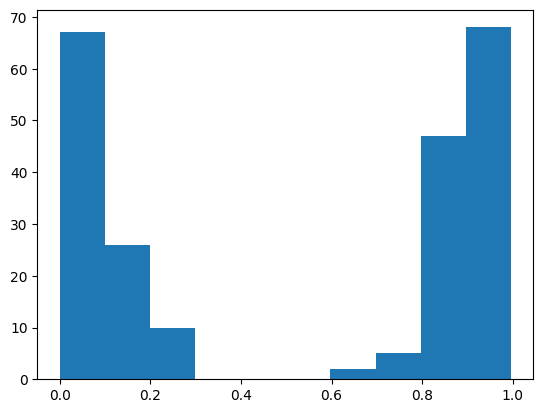

In [455]:
plt.hist(pred_y)

In [427]:
pos_idxs = np.argwhere(pred_y == 1).flatten()

In [428]:
jibar_docs[pred_y < 0.5]

link
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-03/ed-1/seq-2/    (creído, ver, algo, con, que, jamás, soñaron, ...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (cuando, creemos, que, nadie, había, \n, de, p...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-20/ed-1/seq-2/    (secunoart, io, esünwa, fsa, libe-at, que, com...
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-27/ed-1/seq-3/    (Al, hacer, la, explosión, ,, un, jíbaro, que, ;)
https://chroniclingamerica.loc.gov/lccn/sn90070270/1897-03-29/ed-1/seq-3/    (Kpecia'ista, en, la, curación, de, \n, las, e...
                                                                                                   ...                        
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-5/    (|, \n, Girls, ,, Learm, Shorthand, ;, \n, |, ...
https://chroniclingamerica.loc.gov/lccn/sn88073003/1918-11-02/ed-1/seq-2/    (El, sol, era, un, derroche, 

In [316]:
len(responses)

167

In [429]:
len(jibar_docs)

2825

In [264]:
jibar_docs[pos_idxs]

/var/folders/nw/4k8cbbj93j9gvknkvl_w8c1c0000gq/T/ipykernel_57738/971559592.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  jibar_docs[pos_idxs]


Series([], Name: doc_cleaned, dtype: object)

In [68]:
def get_term_freqs(docs):
    tf = defaultdict(int)
    for t in itertools.chain.from_iterable(docs):
        t = t.lower_
        # Remove spanish stop words and punctuation
        if t in nlp.Defaults.stop_words or t in '.,;:!?()[]{}"\'`~@#$%^&*+=-_<>|\\' or len(t) < 2:
            continue
        tf[t] += 1
    return {'tf': dict(tf)}


In [466]:
CountVectorizer(

In [467]:
len(selected_docs)

102

In [468]:
# tfs = get_term_freqs(selected_docs.apply(lambda x: get_surrounding_spans_as_doc(x, JIBARO_WORDS, 20)))
tfs = get_term_freqs(selected_docs)

In [469]:
sorted(tfs['tf'].items(), key=lambda item: -item[1])

[('jíbara', 59),
 ('jíbaro', 40),
 ('jibaro', 39),
 ('...', 39),
 ('fué', 28),
 ('jíbaros', 26),
 ('don', 24),
 ('san', 20),
 ('noche', 18),
 ('caballeros', 16),
 ('casa', 15),
 ('juan', 15),
 ('periódico', 13),
 ('do', 12),
 ('obra', 12),
 ('fiesta', 12),
 ('so', 11),
 ('ia', 11),
 ('ta', 11),
 ('damas', 11),
 ('colón', 11),
 ('bailes', 11),
 ('titulada', 11),
 ('campos', 11),
 ('rico', 10),
 ('cuba', 10),
 ('manuel', 10),
 ('trajes', 10),
 ('metros', 10),
 ('jibara', 10),
 ('eu', 9),
 ('corrientes', 9),
 ('celebrará', 9),
 ('consejo', 9),
 ('1543', 9),
 ('tradicional', 9),
 ('canciones', 9),
 ('obsequios', 9),
 ('apropiados', 9),
 ('ofrecerán', 9),
 ('con-', 9),
 ('currentes', 9),
 ('vestirán', 9),
 ('típicos', 9),
 ('ádeb', 9),
 ('pablo', 8),
 ('puerto', 8),
 ('ios', 8),
 ('amores', 8),
 ('sargento', 8),
 ('droz', 8),
 ('josé', 7),
 ('caballos', 7),
 ('cosa', 7),
 ('carrera', 7),
 ('cayey', 7),
 ('playa', 7),
 ('gui', 7),
 ('casado', 7),
 ('barrio', 6),
 ('fen', 6),
 ('recibe', 6),


In [ ]:
(jibar --> Gibar
